## 1  Install necessary packages


In [ ]:
!pip install qwen-vl-utils  # Upgrade Qwen-VL utilities


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.4/35.4 MB 58.1 MB/s eta 0:00:00:00:0100:01


## 2  Imports

In [ ]:
# ── Standard library ────────────────────────────────────────────
import os          # File‑system helpers (paths, env vars, etc.)
import random      # Lightweight randomness (e.g. sample prompts)
import textwrap    # Nicely format long strings for display
import io          # In‑memory byte streams (e.g. image buffers)
import requests    # Simple HTTP requests for downloading assets

# ── Numerical computing ─────────────────────────────────────────
import numpy as np  # Core array maths (fast, vectorised operations)

# ── Deep‑learning stack ─────────────────────────────────────────
import torch  # Tensor library + GPU acceleration
from transformers import (
    Qwen2_5_VLForConditionalGeneration,  # Multimodal LLM (image+text)
    AutoProcessor,                       # Paired tokenizer/feature‑extractor
)

# ── Imaging & visualisation ─────────────────────────────────────
from PIL import Image                    # Pillow: load/save/manipulate images
import matplotlib.pyplot as plt          # Quick plots in notebooks
import matplotlib.patches as patches     # Bounding‑box overlays, etc.

# ── Project‑specific helpers ────────────────────────────────────
from qwen_vl_utils import process_vision_info  # Post‑process Qwen outputs

# ── Notebook conveniences ──────────────────────────────────────
import IPython.display as ipd             # Inline display (images, audio, HTML)


## 3  Device & model load

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype="auto",
    device_map="auto"
)
processor = AutoProcessor.from_pretrained(model_id)

print(f"Model loaded on: {model.device}")


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model loaded on: cuda:0


## 4  Fetch or upload an image

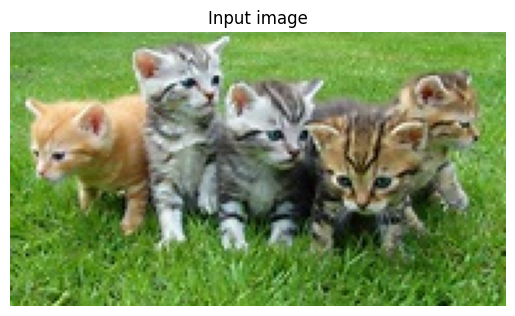

In [ ]:
url = "https://up.yimg.com/ib/th/id/OIP.BAx3AP7S-q1MDst1xn7FfAHaEH?pid=Api&rs=1&c=1&qlt=95&w=190&h=105"
img = Image.open(io.BytesIO(requests.get(url, timeout=15).content)).convert("RGB")

# Display the image
plt.imshow(img)
plt.axis("off")
plt.title("Input image")
plt.show()


## 5  Build a chat-style prompt
### 5.1 Create a message in JSON format

In [ ]:
msgs = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": img},
            {"type": "text",  "text": "Describe this image."}
        ],
    }
]

### 5.2 Apply Chat Template

In [ ]:
# Build the full textual prompt that Qwen-VL expects
# --------------------------------------------------
# • msgs : list of message dicts (roles + content, including <image> markers)
# • tokenize=False : return a plain string—not token IDs—so we can
#                    combine it with image tensors in the next processor() call
# • add_generation_prompt=True : appends the “assistant is about to speak” marker
#                                (e.g. "<|im_start|>assistant\n"), which tells the
#                                model where its reply should begin.
text_prompt = processor.apply_chat_template(
    msgs,
    tokenize=False,
    add_generation_prompt=True
)

# For sanity-checking: print the raw prompt string that will be fed to the model
print(text_prompt)


<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>Describe this image.<|im_end|>
<|im_start|>assistant



### 5.3 Extract image & video inputs from `msg`

In [ ]:
# Extract vision-modalities from msgs and convert them to model-ready tensors

image_inputs, video_inputs = process_vision_info(msgs)


## 6  Generate the caption
### 6.1 Run inference

In [ ]:
# ── Pack text + vision into model-ready tensors ──────────────────────────────
inputs = processor(
    text=[text_prompt],      # 1-element batch containing the chat prompt string
    images=image_inputs,     # list of raw PIL images (pre-processed inside processor)
    videos=video_inputs,     # list of raw video clips (if any)
    padding=True,            # pad sequences so text/vision tokens line up in a batch
    return_tensors="pt",     # return a dict of PyTorch tensors (input_ids, pixel_values, …)
).to(model.device)           # move every tensor—text & vision—to the model’s GPU/CPU

# ── Run inference (no gradients, pure generation) ───────────────────────────
with torch.no_grad():                     # disable autograd to save memory
    generated_ids = model.generate(       # autoregressive decoding
        **inputs,                         # unpack dict into generate(...)
        max_new_tokens=64                 # cap the response at 64 tokens
    )
print(inputs.input_ids[0])
print(generated_ids)

tensor([151644,   8948,    198,   2610,    525,    264,  10950,  17847,     13,
        151645,    198, 151644,    872,    198, 151652, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
        151655, 151655, 151655, 151655, 151655, 151655, 151655, 151653,  74785,
           419,   2168,     13, 151645,    198, 151644,  77091,    198],
       device='cuda:0')
tensor([[151644,   8948,    198,   2610,    525,    264,  10950,  17847,     13,
         151645,    198, 151644,    872,    198, 151652, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151653,  74785,
            419,   2168,     13, 151645,    198, 151644,  77091,    198,    785,
           2168, 

### 6.2 Decode output

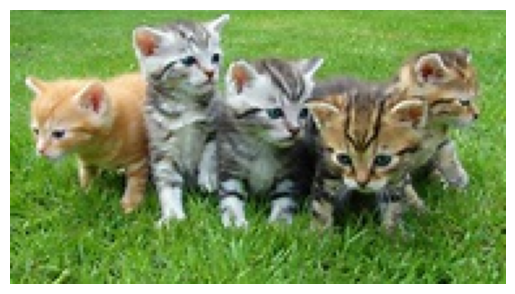

The image shows four kittens standing on a grassy surface. The kittens appear to
be of similar age and size, with short fur and alert expressions. They are
looking in different directions, suggesting they might be curious about
something off-camera. The grass is green and well-maintained, indicating that
the setting might be a


In [ ]:
# Extract the newly generated tokens
caption = processor.batch_decode(
    generated_ids[:, inputs.input_ids.shape[-1]:],
    skip_special_tokens=True
)[0]

# Display the image
plt.imshow(img)
plt.axis("off")
plt.show()

# Print caption
width = 80
wrapped_caption = textwrap.fill(caption, width)
print(wrapped_caption)


# 🚀🚀🚀🚀 Done
